# Tutorial for running MS2Query and creating your own libraries

### Download already created library

In [57]:
import requests
import os
from tqdm import tqdm

def download_file(link, file_name):
    response = requests.get(link, stream=True)
    if os.path.exists(file_name):
        print(f"The file {file_name} already exists, the file won't be downloaded")
        return
    total_size = int(response.headers.get('content-length', 0))

    with open(file_name, "wb") as f, tqdm(desc="Downloading file", total=total_size, unit='B', unit_scale=True, unit_divisor=1024,) as bar:
        for chunk in response.iter_content(chunk_size=1024):
            if chunk:
                f.write(chunk)
                bar.update(len(chunk))  # Update progress bar by the chunk size
folder_to_store_zenodo_files = "./zenodo_files/full_library"
os.makedirs(folder_to_store_zenodo_files, exist_ok=True)

In [54]:
download_file("https://zenodo.org/records/19206616/files/embeddings.npz?download=1", 
              os.path.join(folder_to_store_zenodo_files, "embeddings.npz"))
download_file("https://zenodo.org/records/19206616/files/library_metadata.parquet?download=1", 
              os.path.join(folder_to_store_zenodo_files, "library_metadata.parquet"))
download_file("https://zenodo.org/records/19206616/files/ms2deepscore_model?download=1", 
              os.path.join(folder_to_store_zenodo_files, "ms2deepscore_model.pt"))
download_file("https://zenodo.org/records/19206616/files/top_k_tanimoto_scores.parquet?download=1", 
              os.path.join(folder_to_store_zenodo_files, "top_k_tanimoto_scores.parquet"))

The file ./zenodo_files/full_library/embeddings.npz already exists, the file won't be downloaded
The file ./zenodo_files/full_library/library_metadata.parquet already exists, the file won't be downloaded


Downloading


The file ./zenodo_files/full_library/top_k_tanimoto_scores.parquet already exists, the file won't be downloaded


# initialize reference library

In [60]:
from ms2query.ms2query_development.ReferenceLibrary import ReferenceLibrary
from pathlib import Path
reference_library = ReferenceLibrary.load_from_files(os.path.join(folder_to_store_zenodo_files, "ms2deepscore_model.pt"),
                                                    os.path.join(folder_to_store_zenodo_files, "embeddings.npz"),
                                                    os.path.join(folder_to_store_zenodo_files, "top_k_tanimoto_scores.parquet"),
                                                    os.path.join(folder_to_store_zenodo_files, "library_metadata.parquet"))

# Or directly find the files from a directory
# reference_library = ReferenceLibrary.load_from_directory(Path(folder_to_store_zenodo_files))

# Run MS2Query

In [63]:
test_spectra = list(tqdm(load_from_mgf("../../tests/test_data/10_spectra.mgf")))

10it [00:00, 83.01it/s]


In [64]:
reference_library.run_ms2query(test_spectra)

Hashing spe
Computing s
Predicting 
/lustre/BIF/nobackup/jonge094/ms2query_2/ms2query/ms2query_development/ReferenceLibrary.py:168: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # construct results df


,precursor_mz,retention_time,collision_energy,compound_name,smiles,inchikey,spectrum_hashes,ms2query_reliability_prediction
29144,181.06100,NaN,None,Nicotinuric acid,O=C(O)CNC(=O)c1cccnc1,ZBSGKPYXQINNGF-UHFFFAOYSA-N,4538586676799711060475687385406365205312522933...,0.524193
29138,181.06100,NaN,None,Nicotinuric acid,O=C(O)CNC(=O)c1cccnc1,ZBSGKPYXQINNGF-UHFFFAOYSA-N,4691175720354550216218758199469384349519880571...,0.477547
29139,181.06100,NaN,None,Nicotinuric acid,O=C(O)CNC(=O)c1cccnc1,ZBSGKPYXQINNGF-UHFFFAOYSA-N,8126043578764904179452276022324867195623210187...,0.525872
23334,181.00700,NaN,None,"thieno[2,3-d]pyrimidine-4-carboxylic acid",O=C(O)c1ncnc2sccc12,VOXKHPSKDOLCAC-UHFFFAOYSA-N,4621371819674604814601843392349447447010638904...,0.392072
29146,181.06100,NaN,None,Nicotinuric acid,O=C(O)CNC(=O)c1cccnc1,ZBSGKPYXQINNGF-UHFFFAOYSA-N,4605782118791699534560809552554836164365415626...,0.511462
478528,202.04300,NaN,None,thiabendazole,c1ccc2[nH]c(-c3cscn3)nc2c1,WJCNZQLZVWNLKY-UHFFFAOYSA-N,4037303697924680981028453225819741544585843750...,0.487617
209484,323.13902,105.64,20.0,"5-[(2,5-dimethylphenoxy)methyl]-N-(4-pyridinyl...",Cc1ccc(C)c(OCc2ccc(C(=O)Nc3ccncc3)o2)c1,VYTRUHMGFSNSKK-UHFFFAOYSA-N,4704480111668309422204405940015522296005033315...,0.396629
478527,202.04300,NaN,None,thiabendazole,c1ccc2[nH]c(-c3cscn3)nc2c1,WJCNZQLZVWNLKY-UHFFFAOYSA-N,4354824398973859393735759007513142956866549634...,0.472113
912123,330.18200,NaN,None,"N-[(1R,2S)-2-(4-ethoxyphenyl)cyclopropyl]-3,4-...",CCOc1ccc(C2CC2NC(=O)N2CC(=O)N(C)C(C)C2)cc1,FUDGTDMCXMAZHS-UHFFFAOYSA-N,4689876070452517240544538176971004829216063873...,0.487231
478527,202.04300,NaN,None,thiabendazole,c1ccc2[nH]c(-c3cscn3)nc2c1,WJCNZQLZVWNLKY-UHFFFAOYSA-N,4354824398973859393735759007513142956866549634...,0.490491


# Add spectra to an existing library
If you want to add some in house spectra to the existing library the code below does this without recreating all the files for the full library. 
The last step, computing the top-8 closest tanimoto has to be fully recomputed, which on a laptop will take a few hours. However, if you have a GPU available it is much faster.

In [ ]:
from ms2query.ms2query_development.ReferenceLibrary import ReferenceLibrary
from matchms.importing.load_spectra import load_spectra
from tqdm import tqdm
reference_library = ReferenceLibrary.load_from_files(os.path.join(folder_to_store_zenodo_files, "ms2deepscore_model.pt"),
                                                    os.path.join(folder_to_store_zenodo_files, "embeddings.npz"),
                                                    os.path.join(folder_to_store_zenodo_files, "top_k_tanimoto_scores.parquet"),
                                                    os.path.join(folder_to_store_zenodo_files, "library_metadata.parquet"))

# Clean the spectra first, they will need annotations, smiles, inchi, inchikey. You can use matchms for this. 
test_spectra = list(tqdm(load_spectra("../../tests/test_data/10_spectra.mgf")))

reference_library.add_spectra(test_spectra)
reference_library.save(store_file_directory="./model_with_extra_spectra")

# Create a new MS2Query reference library
Here we show how to create the reference library that can be downloaded from Zenodo. But if you want to make your own of course replace with your own files (no need to download the library)

 For small libraries it is recommended to just add them to the existing libraries instead of creating a small (e.g. <10000 compounds) reference library, since we did not test the uncertainty estimation of MS2Query for small libraries. If you really only care about this small reference library, you can also consider just running MS2DeepScore, since the risk on false positives is much smaller for a small reference library. 

In [2]:
download_file("https://zenodo.org/records/16882111/files/merged_and_cleaned_libraries_1.mgf?download=1", 
              os.path.join(folder_to_store_zenodo_files, "merged_and_cleaned_libraries_1.mgf"))
download_file("https://zenodo.org/records/17826815/files/ms2deepscore_model.pt?download=1", 
              os.path.join(folder_to_store_zenodo_files, "ms2deepscore_model.pt"))

NameError: name 'download_file' is not defined

In [ ]:
library_spectra = list(tqdm(load_from_mgf(os.path.join(folder_to_store_zenodo_files, "merged_and_cleaned_libraries_1.mgf"))))

### Creates the library and saves all the files for future usage. (the files you can also just download above)

In [ ]:
from pathlib import Path

reference_library = ReferenceLibrary.create_from_spectra(library_spectra, os.path.join(folder_to_store_zenodo_files, "ms2deepscore_model.pt"))
reference_library.save(Path(os.path.join(folder_to_store_zenodo_files, "full_library")))

Get most common inchi per inchikey: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 67648/67648 [00:03<00:00, 17833.31it/s]
Adding fingerprints to Inchikeys: 67648it [10:40, 105.60it/s]


# Sanity check that benchmarking resuls also work with new library creation
Not part of the tutorial, just internal documentation. We test the negative in negative library searching. To check that it matches the original benmarking notebook. 

In [3]:
os.makedirs(folder_to_store_zenodo_files, exist_ok=True)
# This file contains the inchikeys used for the data split. This ensures reproducing the exact same results, 
# alternatively you can of course do the data split yourself, but results might differ slightly. 
download_file("https://zenodo.org/records/18801895/files/data_split_inchikeys.json?download=1", 
              os.path.join(folder_to_store_zenodo_files, "data_split_inchikeys.json"))
download_file("https://zenodo.org/records/16882111/files/merged_and_cleaned_libraries_1.mgf?download=1", 
              os.path.join(folder_to_store_zenodo_files, "merged_and_cleaned_libraries_1.mgf"))
download_file("https://zenodo.org/records/17826815/files/ms2deepscore_model.pt?download=1", 
              os.path.join(folder_to_store_zenodo_files, "ms2deepscore_model.pt"))

The file ./zenodo_files/data_split_inchikeys.json already exists, the file won't be downloaded
The file ./zenodo_files/merged_and_cleaned_libraries_1.mgf already exists, the file won't be downloaded
The file ./zenodo_files/ms2deepscore_model.pt already exists, the file won't be downloaded


In [ ]:
from matchms.importing import load_from_mgf
from tqdm import tqdm
import os
library_spectra = list(tqdm(load_from_mgf(os.path.join(folder_to_store_zenodo_files, "merged_and_cleaned_libraries_1.mgf"))))

730577it [04:27, 2631.43it/s]

In [ ]:
import json

with open(os.path.join(folder_to_store_zenodo_files, "data_split_inchikeys.json"), "r") as f:
    data_split = json.load(f)

In [ ]:
val_inchikeys = set(data_split["val"])
train_inchikeys = set(data_split["train"])
test_inchikeys = set(data_split["test"])

In [ ]:
val_spectra = []
test_spectra = []
train_spectra = []
for spectrum in tqdm(library_spectra):
    inchikey = spectrum.get("inchikey")[:14]
    if inchikey in train_inchikeys:
        train_spectra.append(spectrum)
    elif inchikey in val_inchikeys:
        val_spectra.append(spectrum)
    elif inchikey in test_inchikeys:
        test_spectra.append(spectrum)
    else:
        raise ValueError(f"The inchikey {inchikey} does not appear in the val, test or train inchikeys")

In [19]:
def split_on_ionmode(spectra):
    pos_spectra = []
    neg_spectra = []
    for spectrum in spectra:
        ionmode = spectrum.get("ionmode")
        if ionmode == "positive":
            pos_spectra.append(spectrum)
        elif ionmode == "negative":
            neg_spectra.append(spectrum)
        else:
            raise ValueError(f"The ionmode {ionmode} is not positive or negative")
    return pos_spectra, neg_spectra

In [20]:
pos_val_spectra, neg_val_spectra = split_on_ionmode(val_spectra)
pos_test_spectra, neg_test_spectra = split_on_ionmode(test_spectra)
pos_train_spectra, neg_train_spectra = split_on_ionmode(train_spectra)

In [ ]:
from ms2query.ms2query_development.ReferenceLibrary import ReferenceLibrary
reference_library = ReferenceLibrary.create_from_spectra(neg_train_spectra, os.path.join(folder_to_store_zenodo_files, "ms2deepscore_model.pt"))

Computing spectral embeddings ...:  11%|██████████                                                                                    | 30305/283790 [00:31<04:24, 958.90it/s]

In [ ]:
results = reference_library.run_ms2query(neg_val_spectra)

In [27]:
results.to_csv(os.path.join(folder_to_store_zenodo_files, "neg_neg_results.csv"))

In [28]:
results

,precursor_mz,retention_time,collision_energy,compound_name,smiles,inchikey,spectrum_hashes,ms2query_reliability_prediction
4574,266.05894,69.35,30.0,379724-54-6,O=C(O)C1CCN(C(=O)c2ccc(Cl)cc2)CC1,FGLQAKJRFPNIJT-UHFFFAOYSA-N,4287947218867478945721777143654811527279348390...,0.739373
4576,266.05894,69.35,60.0,379724-54-6,O=C(O)C1CCN(C(=O)c2ccc(Cl)cc2)CC1,FGLQAKJRFPNIJT-UHFFFAOYSA-N,8445518326529625949101509334596600018097006285...,0.605217
4574,266.05894,69.35,30.0,379724-54-6,O=C(O)C1CCN(C(=O)c2ccc(Cl)cc2)CC1,FGLQAKJRFPNIJT-UHFFFAOYSA-N,4287947218867478945721777143654811527279348390...,0.739373
4578,266.05900,NaN,None,379724-54-6,O=C(O)C1CCN(C(=O)c2ccc(Cl)cc2)CC1,FGLQAKJRFPNIJT-UHFFFAOYSA-N,4453904535900060540047468210876322356832506165...,0.759073
4581,266.05900,NaN,None,379724-54-6,O=C(O)C1CCN(C(=O)c2ccc(Cl)cc2)CC1,FGLQAKJRFPNIJT-UHFFFAOYSA-N,4438257318628859128622642248978796499540902384...,0.770879
...,...,...,...,...,...,...,...,...
283597,740.52030,NaN,45.0,PE 36:3,CCCCCC=CCC=CCCCCCCCC(=O)OC(COC(=O)CCCCCCCC=CCC...,GKAFCSRKMWFPSJ-UHFFFAOYSA-N,4605131291822750236269081691830926191534825838...,0.943663
283597,740.52030,NaN,45.0,PE 36:3,CCCCCC=CCC=CCCCCCCCC(=O)OC(COC(=O)CCCCCCCC=CCC...,GKAFCSRKMWFPSJ-UHFFFAOYSA-N,4605131291822750236269081691830926191534825838...,0.943663
201773,744.55300,NaN,20.0,PE(18:0_18:1) - (2-aminoethoxy)[2-[octadec-9-e...,CCCCCCCCC=CCCCCCCCC(=O)OC(COC(=O)CCCCCCCCCCCCC...,JQKOHRZNEOQNJE-UHFFFAOYSA-N,8543555785430847640307667357763008254598100629...,0.921203
235132,766.54100,NaN,30.0,"1-Octadecanoyl-2-(5Z,8Z,11Z,14Z-eicosatetraeno...",CCCCCC=CCC=CCC=CCC=CCCCC(=O)OC(COC(=O)CCCCCCCC...,ANRKEHNWXKCXDB-UHFFFAOYSA-N,4772335068029728878564587931928277302571040079...,0.907530


In [37]:
predicted_inchikeys = [inchikey[:14] for inchikey in results["inchikey"].tolist()]

In [38]:
predicted_scores = results["ms2query_reliability_prediction"].tolist()

In [42]:
import pickle
import os
intermediates_folder = "./cross_ionmode_intermediate"

with open(os.path.join(intermediates_folder, "all_fingerprints.pickle"), "rb") as handle:
    all_fingerprints = pickle.load(handle)


In [44]:
from tqdm import tqdm
from matchms.similarity.vector_similarity_functions import jaccard_similarity_matrix
import numpy as np
def get_prediction_tanimoto(predicted_inchikeys, val_spectra, val_and_train_fingerprints):
    assert len(predicted_inchikeys) == len(val_spectra)

    tanimoto_for_prediction = []
    for index, predicted_inchikey in enumerate(tqdm(predicted_inchikeys)):
        if predicted_inchikey is not None:
            correct_inchikey = val_spectra[index].get("inchikey")[:14]
            predicted_fingerprint = val_and_train_fingerprints.get_fingerprints([predicted_inchikey])[0]
            actual_fingerprint = val_and_train_fingerprints.get_fingerprints([correct_inchikey])[0]
            tanimoto_prediction = jaccard_similarity_matrix(np.array([predicted_fingerprint]), np.array([actual_fingerprint]))[0][0]
            tanimoto_for_prediction.append(tanimoto_prediction)
        else:
            tanimoto_for_prediction.append(0.0)
    return tanimoto_for_prediction

In [45]:
neg_neg_tanimoto_for_prediction = get_prediction_tanimoto(predicted_inchikeys, neg_val_spectra, all_fingerprints)

100%|███████████████████████████████████████████████████████████████████████████████| 15967/15967 [00:00<00:00, 18131.11it/s]


In [49]:
import numpy as np

def create_values_violin_plot(predicted_scores, val_spectra, tanimoto_for_predictions, n_buckets):
    """The predictions are ranked based on the predicted scores, and are split in different groups from high to low, 
    for each group the average tanimoto per inchikey is computed."""
    tanimoto_per_bucket = []
    ranked_indexes_per_bucket = bucket_by_value(predicted_scores, n_buckets)
    for indexes_in_bucket in ranked_indexes_per_bucket: 
        average_tanimoto_per_inchikey = get_average_tanimoto_per_inchikey(val_spectra, tanimoto_for_predictions, indexes_in_bucket)
        tanimoto_per_bucket.append(average_tanimoto_per_inchikey)
    return tanimoto_per_bucket

def bucket_by_value(values, n_buckets=10):
    """
    Splits values into n equally sized buckets based on rank. 
    So the highest scores are in the first bucket en the lowest in the last. Each bucket has the same number of values. 
    """
    values = np.array(values)
    # Get indexes that would sort the array descending (top values first)
    sorted_indexes = np.argsort(values)[::-1]
    
    # Split sorted indexes into n equal(ish) buckets
    buckets = np.array_split(sorted_indexes, n_buckets)
    
    return buckets
    
def get_average_tanimoto_per_inchikey(query_spectrum_set, tanimoto_for_predictions, selected_indexes):
    """Calculates the average tanimoto per inchikey for the selected indexes"""
    assert len(tanimoto_for_predictions) == len(query_spectrum_set)
    average_scores_per_inchikey = []
    # Calculate score per unique inchikey
    for inchikey in query_spectrum_set.spectrum_indices_per_inchikey.keys():
        matching_spectrum_indexes = query_spectrum_set.spectrum_indices_per_inchikey[inchikey]
        prediction_scores = []
        for index in matching_spectrum_indexes:
            if index in selected_indexes:
                prediction_scores.append(tanimoto_for_predictions[index])
        if len(prediction_scores) > 0:
            average_prediction = sum(prediction_scores) / len(prediction_scores)
            average_scores_per_inchikey.append(average_prediction)
    return average_scores_per_inchikey

def plot_average_per_threshold(predicted_scores, tanimoto_for_predictions, val_spectra, n_of_buckets):
    buckets = bucket_by_value(predicted_scores,n_of_buckets)
    mean_per_fraction = []
    selected_indexes = set()
    for indexes_in_bucket in tqdm(buckets):
        selected_indexes.update(set(indexes_in_bucket.tolist()))
        average_scores_per_inchikey = get_average_tanimoto_per_inchikey(val_spectra, tanimoto_for_predictions, selected_indexes)
        mean = sum(average_scores_per_inchikey)/len(average_scores_per_inchikey)
        mean_per_fraction.append(mean)
    return mean_per_fraction
    
from matplotlib import pyplot as plt

def plot_comparison_plot(results):
    n = len(list(results.values())[0])
    labels = [f"0 - {(100/n)*(i+1)} %" for i in range(n)]
    for label, mean_per_fraction in results.items():
        plt.plot(labels, mean_per_fraction, label = label)
    
    plt.xlabel("Fraction predicted")
    plt.ylabel("Average Tanimoto")
    plt.legend()
    plt.ylim((0, 1))
    
    step = n // 10
    positions = range(len(labels))
    
    plt.xticks(
        ticks=positions[step-1::step],    # start at 9, then 19, 29, ...
        labels=labels[step-1::step],
        rotation=45,
        ha='right'
    )
    plt.grid(axis='both', linestyle='--', alpha=0.5)
    plt.show()

100%|█████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 603.54it/s]


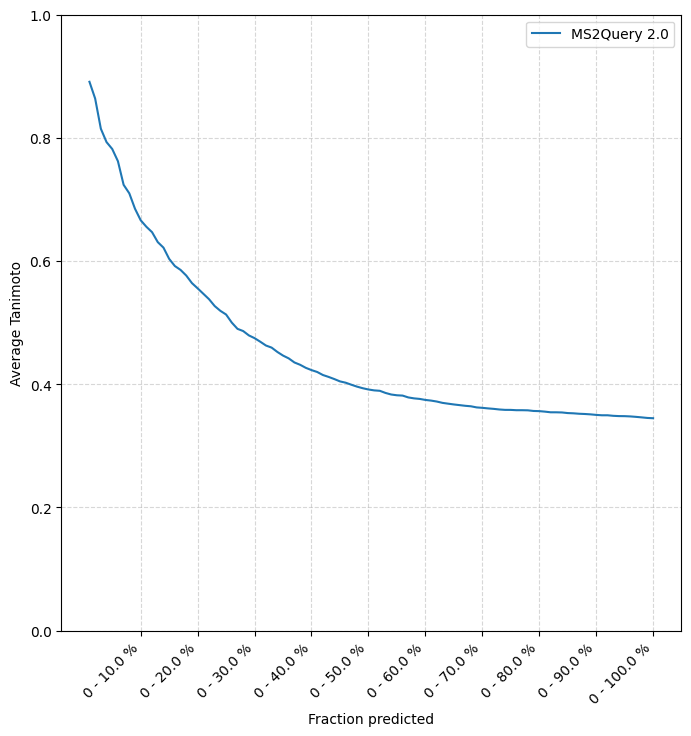

In [51]:
from ms2query.benchmarking.AnnotatedSpectrumSet import AnnotatedSpectrumSet


plt.figure(figsize=(8, 8))
plot_comparison_plot({
    # "MS2DeepScore":  plot_average_per_threshold(ms2deepscores.squeeze(), neg_neg_tanimoto_for_prediction_ms2deepscore, neg_val_spectra, 100),
    "MS2Query 2.0": plot_average_per_threshold(predicted_scores, neg_neg_tanimoto_for_prediction, AnnotatedSpectrumSet.create_spectrum_set(neg_val_spectra), 100),
})